In [1]:
import numpy as np # Linear Algebra
import scipy # For matrix exponential
import matplotlib.pyplot as plt # Plotting

In [2]:
#Continuous-time dynamics model
g = 9.8
Ac = np.array([[0., 1.], [0., 0.]])
cc = np.array([[0], [-g]])

In [3]:
#Create discrete-time dynamics model
dt = 0.1
D = np.block([[Ac, cc],[0, 0, 0]])
M = scipy.linalg.expm(dt*D)
A = M[0:2,0:2]
c = M[0:2,2]

In [4]:
#Noise covariances
V = 0.01*np.eye(2) #process noise
W = 1.0 #measurment noise

In [5]:
#Initial conditions
x0 = np.random.multivariate_normal(np.zeros((2,)), np.eye(2))

In [6]:
#Simulate with process noise
Tfinal = 2.0
Nt = 21
xtraj = np.zeros((2, Nt))
xtraj[:,0] = x0
for k in range(Nt-1):
    xtraj[:,k+1] = A@xtraj[:,k] + c + np.random.multivariate_normal(np.zeros((2,)), V)

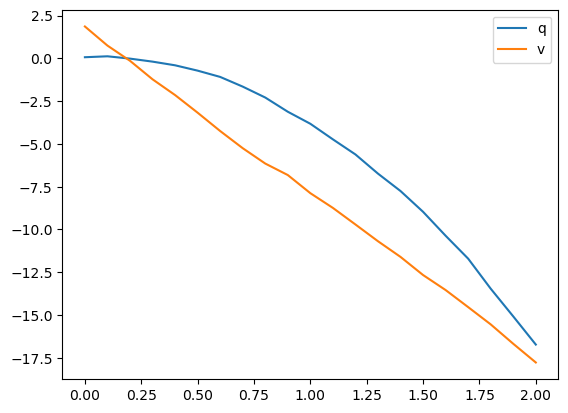

In [7]:
times = np.linspace(0,Tfinal,Nt)
plt.plot(times, xtraj[0,:], label='q')
plt.plot(times, xtraj[1,:], label='v')
plt.legend()

In [8]:
# Generate noisy measurements
ytraj = xtraj[0,:] + np.random.normal(0, W, Nt)

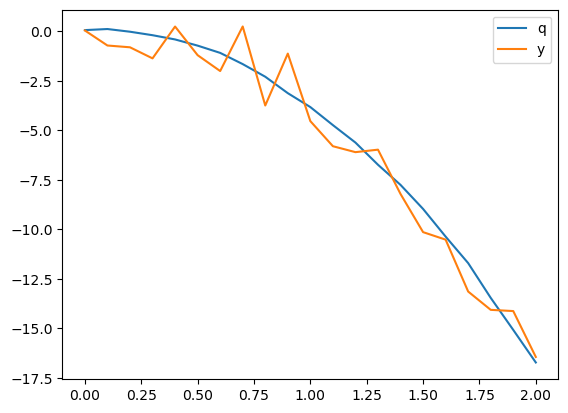

In [9]:
plt.plot(times, xtraj[0,:], label='q')
plt.plot(times, ytraj, label='y')
plt.legend()

In [10]:
# Define the measurement model
C = np.array([1., 0.])

In [11]:
#Filter Initialization
xfilt = np.zeros((2,Nt))
xfilt[:,0] = np.random.multivariate_normal(xtraj[:,0], np.eye(2))

P = np.zeros((2,2,Nt))
P[:,:,0] = np.eye(2)

In [12]:
for k in range(Nt-1):
    #Prediction
    xpred = A@xfilt[:,k] + c
    Ppred = A@P[:,:,k]@A.T + V

    #Innovation
    z = ytraj[k+1] - C@xpred
    S = C@Ppred@C.T + W

    #Kalman Gain
    L = Ppred@C.T/S

    #Update
    xfilt[:,k+1] = xpred + L*z
    P[:,:,k+1] = (np.eye(2)-L*C)@Ppred@(np.eye(2)-L*C).T + L*W*L.T

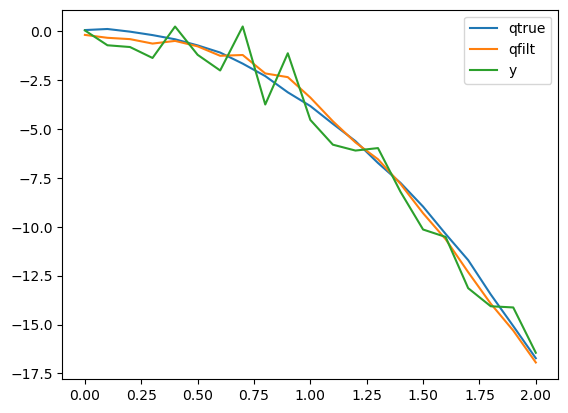

In [13]:
# Plot the estimate vs. the ground truth
plt.plot(times, xtraj[0,:], label='qtrue')
plt.plot(times, xfilt[0,:], label='qfilt')
plt.plot(times, ytraj, label='y')
plt.legend()

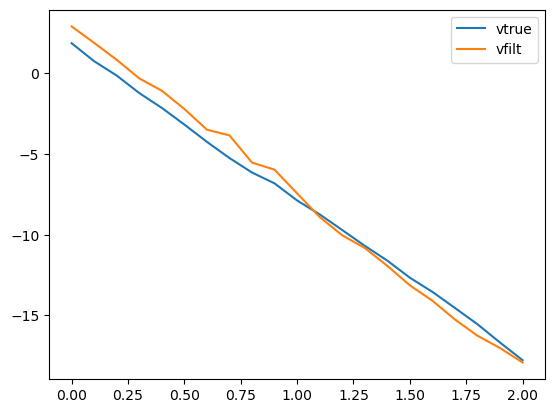

In [14]:
plt.plot(times, xtraj[1,:], label='vtrue')
plt.plot(times, xfilt[1,:], label='vfilt')
plt.legend()

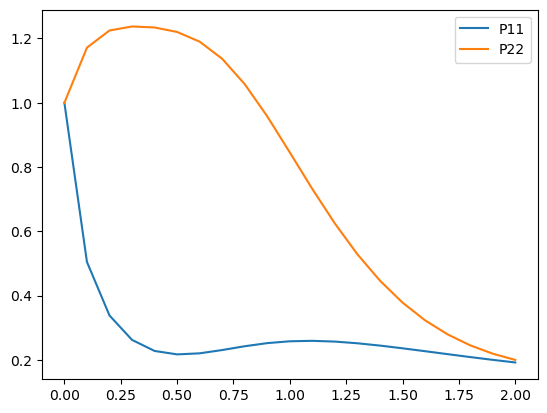

In [15]:
#Plot covariance components
plt.plot(times, P[0,0,:], label='P11')
plt.plot(times, P[1,1,:], label='P22')
plt.legend()